### Import Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns          


In [2]:
df = pd.read_csv("/kaggle/input/farm-produce-data-80-years/farm_production_dataset.csv")


### Define Features (X) and Target (y) & Handle Target Missing Values

In [3]:
TARGET_COLUMN = 'Production (metric tonnes)'
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]
original_rows = df.shape[0]
df_cleaned = df.dropna(subset=[TARGET_COLUMN])
X = df_cleaned.drop(TARGET_COLUMN, axis=1)
y = df_cleaned[TARGET_COLUMN]
print(f"Removed {original_rows - df_cleaned.shape[0]} rows with missing target values.")



Removed 28 rows with missing target values.


### Feature Preprocessing - Imputation

In [4]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

num_imputer = SimpleImputer(strategy='mean')
X_numerical = X[numerical_features]
X[numerical_features] = num_imputer.fit_transform(X_numerical)

cat_imputer = SimpleImputer(strategy='most_frequent')
X_categorical = X[categorical_features]
X[categorical_features] = cat_imputer.fit_transform(X_categorical)

### Feature Preprocessing - Encoding and Scaling

In [5]:
original_cols = X.columns.tolist()
X = pd.get_dummies(X, columns=categorical_features, drop_first=True, dummy_na=False)
new_cols = [col for col in X.columns if col not in original_cols]

numerical_features_post_encoding = X.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[numerical_features_post_encoding])

imputer_post_scale = SimpleImputer(missing_values=np.nan, strategy='mean')
X_scaled = imputer_post_scale.fit_transform(X_scaled)
X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=np.finfo(np.float64).max, neginf=np.finfo(np.float64).min)

X[numerical_features_post_encoding] = X_scaled

X.replace([np.inf, -np.inf], np.nan, inplace=True)
final_imputer = SimpleImputer(strategy='mean')
original_columns = X.columns
original_index = X.index
X = final_imputer.fit_transform(X)
X = pd.DataFrame(X, columns=original_columns, index=original_index)


### Train-Test Split and Model Training

In [6]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

X = X.loc[y.index]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"\nSplit data into training ({1-TEST_SIZE:.0%}) and testing ({TEST_SIZE:.0%}) sets.")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, oob_score=True)
model.fit(X_train, y_train)
print(f"Model Out-of-Bag (OOB) R² Score: {model.oob_score_:.4f}")




Split data into training (80%) and testing (20%) sets.
Training features shape: (8196, 41)
Testing features shape: (2049, 41)
Training target shape: (8196,)
Testing target shape: (2049,)
Model Out-of-Bag (OOB) R² Score: 0.8467


### Model Evaluation and Interpretation

In [7]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"R-squared (R²) Score:      {r2:.4f}")



--- Evaluation Metrics ---
Mean Absolute Error (MAE): 38605.3492
Mean Squared Error (MSE):  19059940503.1465
R-squared (R²) Score:      0.9974


### plots

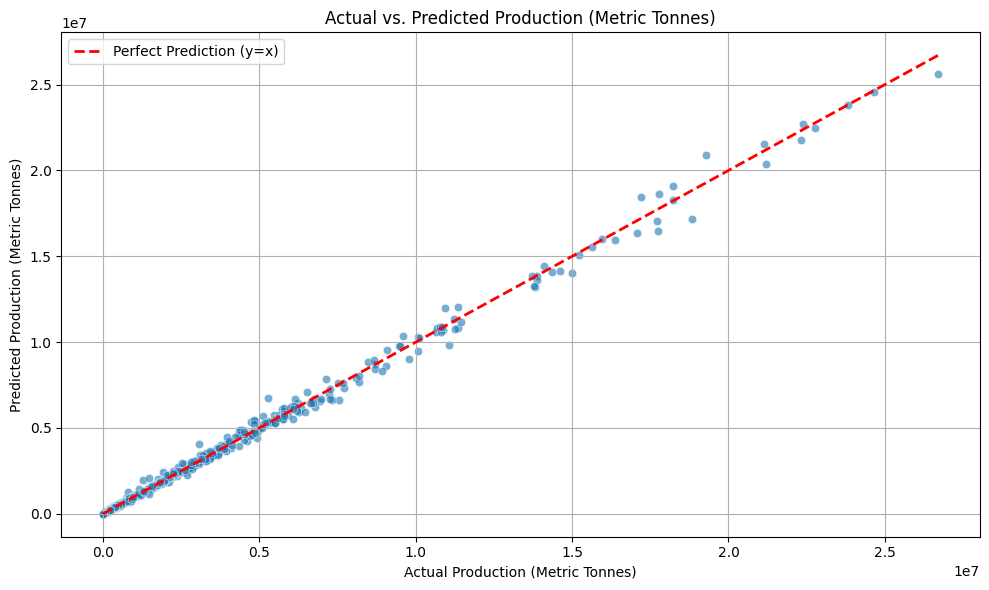

In [8]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction (y=x)')

plt.title('Actual vs. Predicted Production (Metric Tonnes)')
plt.xlabel('Actual Production (Metric Tonnes)')
plt.ylabel('Predicted Production (Metric Tonnes)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




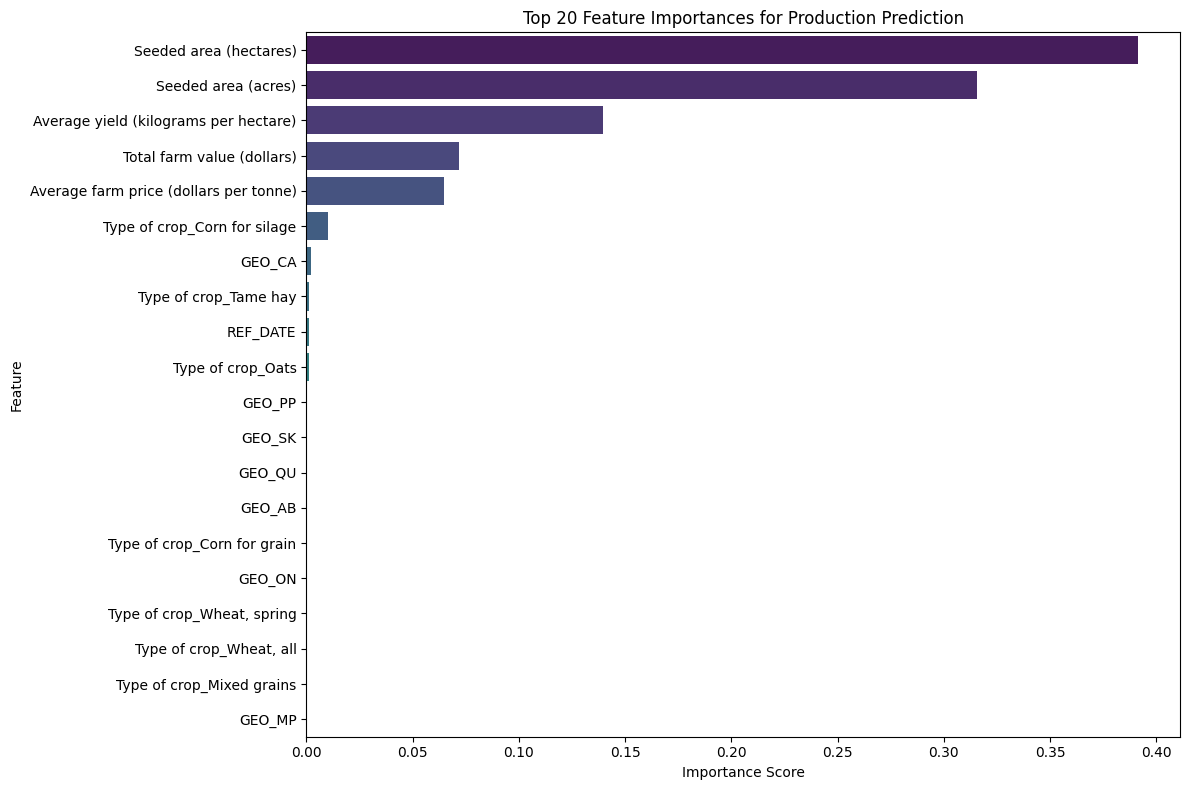

Displayed Top 20 Feature Importance plot.

--- Feature Importances (Top 20) ---
                                   Feature  Importance
4                   Seeded area (hectares)    0.391580
3                      Seeded area (acres)    0.315429
2    Average yield (kilograms per hectare)    0.139650
5               Total farm value (dollars)    0.071652
1   Average farm price (dollars per tonne)    0.064711
23            Type of crop_Corn for silage    0.010217
8                                   GEO_CA    0.002099
36                   Type of crop_Tame hay    0.001330
0                                 REF_DATE    0.001296
28                       Type of crop_Oats    0.001122
16                                  GEO_PP    0.000291
18                                  GEO_SK    0.000202
17                                  GEO_QU    0.000107
6                                   GEO_AB    0.000085
22             Type of crop_Corn for grain    0.000047
14                                  GEO_

In [9]:
importances = model.feature_importances_

current_feature_names = model.feature_names_in_

feature_importance_df = pd.DataFrame({
    'Feature': current_feature_names, 
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(top_n), palette='viridis')
num_features_total = len(current_feature_names)
plt.title(f'Top {min(top_n, num_features_total)} Feature Importances for Production Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
print(f"Displayed Top {min(top_n, num_features_total)} Feature Importance plot.")
print(f"\n--- Feature Importances (Top {min(top_n, num_features_total)}) ---")
print(feature_importance_df.head(top_n).to_string())
